# TCGA Pan-Cancer EDA for Predicting TP53 Mutation Status from RNA Expression

## Objective
Use TCGA RNA expression data to explore whether TP53 mutation status can be predicted from transcriptomic profiles.

## Data sources
- RNA: `tcga_RSEM_gene_tpm.gz`
- Somatic mutations: `mc3.v0.2.8.PUBLIC.xena.gz`
- Clinical / phenotype: `Survival_SupplementalTable_S1_20171025_xena_sp`

## Main EDA goals
1. Define a clean TP53 mutation label
2. Build a sample-level merged dataset
3. Quantify class balance and cohort composition
4. Check cancer-type confounding
5. Inspect RNA quality and structure
6. Identify issues that should shape the modeling notebook

## Key warning
In TCGA, cancer type can strongly confound TP53 prediction because cancer type affects both mutation prevalence and gene expression.

In [1]:
import gzip
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("notebook")

In [2]:
# Flexible paths for local, Colab, and Kaggle runs.
# Keep the raw TCGA/Xena files as the preferred source because they preserve TCGA barcodes.
SEARCH_ROOTS = [Path("./data"), Path("/kaggle/input"), Path("/content"), Path("/mnt/data"), Path(".")]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find required input. Tried:\n" + "\n".join(tried))
    return None

def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        first_line = f.readline()
    return "\t" if first_line.count("\t") >= first_line.count(",") else ","

RNA_PATH = find_first(["tcga_RSEM_gene_tpm.gz", "tcga_RSEM_gene_tpm", "*tcga_RSEM_gene_tpm*"], required=True)
MUT_PATH = find_first(["mc3.v0.2.8.PUBLIC.xena.gz", "mc3.v0.2.8.PUBLIC.xena", "*mc3*PUBLIC*xena*"], required=True)
PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena*",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=True)
TP53_TARGETS_PATH = find_first(["tp53_target_genes_fischer2017.csv", "*tp53_target_genes_fischer2017*.csv"], required=False)
GENE_ANNOTATION_PATH = find_first([
    "*probeMap*", "*gene_annotation*.csv", "*gene_annotation*.tsv",
    "*gencode*.csv", "*gencode*.tsv", "*gencode*annotation*",
], required=False)

RNA_SEP = sniff_sep(RNA_PATH)
MUT_SEP = sniff_sep(MUT_PATH)
PHENO_SEP = sniff_sep(PHENO_PATH)

RANDOM_STATE = 42
TOP_VAR_GENES_FOR_PCA = 2000

print("RNA_PATH =", RNA_PATH)
print("MUT_PATH =", MUT_PATH)
print("PHENO_PATH =", PHENO_PATH)
print("TP53_TARGETS_PATH =", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH =", GENE_ANNOTATION_PATH)

RNA_PATH = data/tcga_RSEM_gene_tpm.gz
MUT_PATH = data/mc3.v0.2.8.PUBLIC.xena.gz
PHENO_PATH = data/Survival_SupplementalTable_S1_20171025_xena_sp
TP53_TARGETS_PATH = data/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH = None


## Load raw TCGA files

First load the RNA, mutation, and phenotype tables and inspect their shape, columns, and identifier formats before making any assumptions.

In [3]:
rna_raw = pd.read_csv(RNA_PATH, sep=RNA_SEP, low_memory=False)
mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
pheno_raw = pd.read_csv(PHENO_PATH, sep=PHENO_SEP, low_memory=False, dtype=str)

print("RNA shape:", rna_raw.shape)
print("Mutation shape:", mut_raw.shape)
print("Phenotype shape:", pheno_raw.shape)

display(rna_raw.head())
display(mut_raw.head())
display(pheno_raw.head())

RNA shape: (60498, 10536)
Mutation shape: (2907335, 12)
Phenotype shape: (12591, 34)


,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01,TCGA-AB-2863-03,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-R6-A8WC-01,TCGA-DX-A3U8-01,TCGA-GL-8500-01,TCGA-E2-A153-11,TCGA-BR-A4J6-01,TCGA-EJ-7125-01,TCGA-IN-7808-01,TCGA-L5-A4OH-01,TCGA-RP-A695-06,TCGA-AX-A3G6-01,TCGA-B9-A8YH-01,TCGA-E1-A7YI-01,TCGA-PC-A5DM-01,TCGA-BR-A4QL-01,TCGA-CH-5751-01,TCGA-A2-A3XX-01,TCGA-DQ-5624-01,TCGA-KK-A7B3-01,TCGA-DQ-7591-01,TCGA-06-5412-01,TCGA-BP-4989-01,TCGA-EJ-8468-01,TCGA-CZ-5459-01,TCGA-D5-5538-01,TCGA-56-8305-01,TCGA-CZ-5468-11,TCGA-BH-A0BQ-11,TCGA-4X-A9FA-01,TCGA-DD-AAW0-01,TCGA-AA-3511-01,TCGA-Z7-A8R5-01,TCGA-CZ-4863-11,TCGA-39-5031-01,TCGA-ZG-A8QW-01,TCGA-DU-7302-01,TCGA-DJ-A3UX-01,TCGA-ZN-A9VQ-01,TCGA-EI-6512-01,TCGA-J4-A83K-01,TCGA-EE-A17X-06,TCGA-HZ-7922-01,TCGA-DD-AACA-02,TCGA-DD-AACA-01,TCGA-D3-A8GD-06,TCGA-13-1485-01,TCGA-QG-A5YX-01,TCGA-ZG-A9MC-01,TCGA-DU-A7TI-01,TCGA-A3-3335-01,TCGA-BR-8372-01,TCGA-HC-7742-01,TCGA-DD-A3A6-11,TCGA-64-1679-01,TCGA-CV-5976-01,TCGA-25-1315-01,TCGA-2G-AAFZ-01,TCGA-LN-A4MQ-01,TCGA-CV-6948-01,TCGA-K7-AAU7-01,TCGA-CJ-6028-01,TCGA-B6-A0RL-01,TCGA-CZ-5456-01,TCGA-EL-A3D0-01,TCGA-EM-A22Q-01,TCGA-49-6744-01,TCGA-L5-A4ON-01,TCGA-FS-A1ZF-06,TCGA-ZN-A9VU-01,TCGA-Q3-A5QY-01,TCGA-AJ-A3BI-01,TCGA-W2-A7UY-01,TCGA-BH-A204-11,TCGA-E3-A3E2-01,TCGA-FB-A545-01,TCGA-44-2657-11,TCGA-G4-6320-01,TCGA-EB-A41A-01,TCGA-55-6982-01,TCGA-RC-A7SH-01,TCGA-CC-A3MA-01,TCGA-DD-A3A5-11,TCGA-RC-A7SB-01,TCGA-CM-6164-01,TCGA-ET-A3BW-01,TCGA-09-0369-01,TCGA-E2-A2P6-01,TCGA-VD-A8KF-01,TCGA-EL-A4JZ-01,...,TCGA-AB-2833-03,TCGA-EE-A2MF-06,TCGA-D8-A1XR-01,TCGA-50-5072-01,TCGA-AB-2964-03,TCGA-HI-7171-01,TCGA-AR-A0TQ-01,TCGA-G3-A3CG-01,TCGA-BB-7863-01,TCGA-DU-6406-01,TCGA-BR-4255-01,TCGA-AA-3675-01,TCGA-JV-A75J-01,TCGA-DD-A1ED-01,TCGA-BH-A18P-01,TCGA-VD-A8KJ-01,TCGA-A6-6782-01,TCGA-BR-A4CR-01,TCGA-2Y-A9H8-01,TCGA-61-1721-01,TCGA-56-8628-01,TCGA-2Y-A9GT-01,TCGA-EO-A3AZ-01,TCGA-3N-A9WD-06,TCGA-29-1784-01,TCGA-2L-AAQI-01,TCGA-HS-A5N9-01,TCGA-VS-A9UT-01,TCGA-E2-A15O-01,TCGA-50-5045-01,TCGA-DA-A95W-06,TCGA-BP-4332-01,TCGA-AO-A12C-01,TCGA-86-8674-01,TCGA-CZ-5451-11,TCGA-FF-8043-01,TCGA-P3-A5Q5-01,TCGA-N8-A4PQ-01,TCGA-50-8457-01,TCGA-ZJ-AAX8-01,TCGA-OL-A97C-01,TCGA-18-3416-01,TCGA-B8-4146-01,TCGA-AB-2937-03,TCGA-56-7222-11,TCGA-68-7755-01,TCGA-EE-A2GN-06,TCGA-V1-A9ZR-01,TCGA-2J-AABK-01,TCGA-EJ-A6RC-01,TCGA-EL-A3GP-01,TCGA-D9-A4Z6-06,TCGA-E2-A15K-11,TCGA-06-0743-01,TCGA-H2-A3RI-01,TCGA-21-5787-01,TCGA-BJ-A18Z-01,TCGA-D7-A6EX-01,TCGA-TM-A84B-01,TCGA-OR-A5K0-01,TCGA-FY-A4B4-01,TCGA-BH-A18G-01,TCGA-13-0725-01,TCGA-B6-A0IA-01,TCGA-A8-A090-01,TCGA-BB-4217-01,TCGA-5T-A9QA-01,TCGA-TN-A7HJ-01,TCGA-AN-A0XT-01,TCGA-TS-A8AS-01,TCGA-J4-8198-01,TCGA-DU-A76O-01,TCGA-EE-A29L-06,TCGA-4X-A9F9-01,TCGA-C5-A1BJ-01,TCGA-G2-AA3C-01,TCGA-HU-8602-01,TCGA-CR-6470-01,TCGA-CH-5768-01,TCGA-2H-A9GM-01,TCGA-XH-A853-01,TCGA-CM-4751-01,TCGA-AO-A0J4-01,TCGA-55-6985-11,TCGA-YL-A9WK-01,TCGA-77-6844-01,TCGA-IN-AB1X-11,TCGA-A2-A0YK-01,TCGA-18-3414-01,TCGA-13-1481-01,TCGA-DJ-A2QC-01,TCGA-A8-A09K-01,TCGA-61-1907-01,TCGA-IB-7885-01,TCGA-95-7947-01,TCGA-VQ-AA6F-01,TCGA-BR-8588-01,TCGA-24-2254-01,TCGA-DD-A115-01,TCGA-FV-A3I0-11
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6873,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.8599,-0.4521,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-4.2934,-3.6259,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-2.5479,-1.2481,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.965800,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6193,-1.3921,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-2.0529,-9.9658,-9.9658,-3.1714,-3.3076,-9.9658,-5.0116,1.0711,-2.1140,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-0.9686,0.1257,-3.4580,-4.2934,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-0.4131,-9.9658,-9.9658,-9.9658,-

,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-21496,Dead,WITH TUMOR,NaN,1355,NaN,Distant Metastasis,Peritoneal Surfaces,NaN,754,Complete Remission/Response,NaN,NaN,1,1355,1,1355,1,754,1,754,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2004,NaN,-16090,Dead,WITH TUMOR,NaN,1677,NaN,Distant Metastasis,Soft Tissue,NaN,289,Progressive Disease,NaN,NaN,1,1677,1,1677,NaN,NaN,1,289,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2008,NaN,-8624,Alive,WITH TUMOR,2091,NaN,NaN,Distant Metastasis,Lung,NaN,53,Complete Remission/Response,NaN,NaN,0,2091,0,2091,1,53,1,53,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-8451,Dead,WITH TUMOR,NaN,423,NaN,Locoregional Recurrence,Peritoneal Surfaces,NaN,126,Progressive Disease,NaN,NaN,1,423,1,423,NaN,NaN,1,126,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-11171,Dead,WITH TUMOR,NaN,365,NaN,Locoregional Recurrence,"Other, specify",vena cava thrombus,50,Progressive Disease,NaN,NaN,1,365,1,365,NaN,NaN,1,50,NaN


In [4]:
print("RNA columns (first 20):", list(rna_raw.columns[:20]))
print("Mutation columns:", list(mut_raw.columns[:30]))
print("Phenotype columns:", list(pheno_raw.columns[:50]))

RNA columns (first 20): ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03', 'TCGA-C8-A1HL-01', 'TCGA-EW-A2FS-01', 'TCGA-IR-A3L7-01', 'TCGA-05-4420-01', 'TCGA-R6-A8WC-01', 'TCGA-DX-A3U8-01', 'TCGA-GL-8500-01', 'TCGA-E2-A153-11', 'TCGA-BR-A4J6-01', 'TCGA-EJ-7125-01', 'TCGA-IN-7808-01', 'TCGA-L5-A4OH-01']
Mutation columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
Phenotype columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tu

In [5]:
# Helpful schema inspection
for name, df in [("rna_raw", rna_raw), ("mut_raw", mut_raw), ("pheno_raw", pheno_raw)]:
    print(f"\n{name}")
    print(df.dtypes.head(20))
    print(df.isna().mean().sort_values(ascending=False).head(10))


rna_raw
sample                 str
TCGA-19-1787-01    float64
TCGA-S9-A7J2-01    float64
TCGA-G3-A3CH-11    float64
TCGA-EK-A2RE-01    float64
TCGA-44-6778-01    float64
TCGA-F4-6854-01    float64
TCGA-AB-2863-03    float64
TCGA-C8-A1HL-01    float64
TCGA-EW-A2FS-01    float64
TCGA-IR-A3L7-01    float64
TCGA-05-4420-01    float64
TCGA-R6-A8WC-01    float64
TCGA-DX-A3U8-01    float64
TCGA-GL-8500-01    float64
TCGA-E2-A153-11    float64
TCGA-BR-A4J6-01    float64
TCGA-EJ-7125-01    float64
TCGA-IN-7808-01    float64
TCGA-L5-A4OH-01    float64
dtype: object
sample             0.0
TCGA-3G-AB0O-01    0.0
TCGA-M7-A720-01    0.0
TCGA-HC-7080-01    0.0
TCGA-29-1768-01    0.0
TCGA-55-7910-01    0.0
TCGA-A6-5667-01    0.0
TCGA-ZC-AAAF-01    0.0
TCGA-85-8288-01    0.0
TCGA-B6-A0RI-01    0.0
dtype: float64

mut_raw
sample               str
chr                  str
start                str
end                  str
reference            str
alt                  str
gene                 str
effect  

### Schema decisions from inspection

The notebook below infers the core schema rather than relying on hand-filled placeholders:

- RNA layout is detected as either gene × sample or sample × gene.
- Mutation sample barcodes, mutation gene symbols, and mutation effect columns are inferred from common TCGA/Xena column names.
- Phenotype sample IDs, patient IDs, and cancer type columns are inferred from common TCGA/Xena column names.
- Patient IDs used for cohort audits come from phenotype/sample barcodes for **all** samples, not only from TP53 mutation-positive rows.

In [6]:
def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        key = norm_name(cand)
        if key in normalized:
            return normalized[key]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None

def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))

def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))

def normalize_patient_id(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s

def normalize_sample_id(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s

# Backwards-compatible aliases used in a few cells below.
tcga_patient_id = normalize_patient_id
tcga_sample_id = normalize_sample_id

TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}
TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}
SAMPLE_PRIORITY = {"01": 0, "03": 1, "06": 2, "02": 3, "05": 4, "07": 5, "08": 6, "09": 7, "04": 8}

def tcga_sample_type_code(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan

def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan

def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

def infer_rna_orientation(df):
    cols = list(df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]
    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}
    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0
    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    preview_first_values = df.iloc[: min(len(df), 10), 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5:
        return "sample_x_gene"
    if sample_named_first:
        return "sample_x_gene"
    return "gene_x_sample"

In [7]:
MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type", "VariantType"], "Variant type", required=False),
        find_col(mut_raw, ["Protein_Change", "ProteinChange", "Amino_Acid_Change"], "protein change", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert MUT_EFFECT_COLS, "No mutation-effect columns were found; TP53 label cannot be built safely."

PHENO_SAMPLE_COL = find_col(
    pheno_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "phenotype sample column",
)
PHENO_PATIENT_COL = find_col(
    pheno_raw,
    ["patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "phenotype patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    pheno_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen phenotype sample column:", PHENO_SAMPLE_COL)
print("Chosen phenotype patient column:", PHENO_PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect', 'Amino_Acid_Change']
Chosen phenotype sample column: sample
Chosen phenotype patient column: _PATIENT
Chosen cancer type column: cancer type abbreviation


### Recommendation
Prefer a **sample-level merge** for EDA first, then later decide whether to collapse to one sample per patient for modeling.

If multiple tumour samples exist per patient, that is a leakage risk for the modeling notebook and must be handled explicitly there.

In [8]:
rna = rna_raw.copy()
RNA_ORIENTATION = infer_rna_orientation(rna)
RNA_FIRST_COL = rna.columns[0]

print("RNA first column name:", RNA_FIRST_COL)
print("First few column names:", list(rna.columns[:5]))
print("Inferred RNA orientation:", RNA_ORIENTATION)

RNA first column name: sample
First few column names: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01']
Inferred RNA orientation: gene_x_sample


In [9]:
gene_col = RNA_FIRST_COL
rna_longcheck = rna.iloc[:5, :5]
display(rna_longcheck)

if RNA_ORIENTATION == "gene_x_sample":
    # Common Xena format: first column is gene identifier, remaining columns are sample IDs.
    rna_mat = rna.set_index(gene_col).T
    rna_mat.index = pd.Index(rna_mat.index.map(normalize_sample_id), name="sample_id")
    rna_mat = rna_mat.apply(pd.to_numeric, errors="coerce")
    # Multiple aliquots can collapse to the same sample ID after barcode normalization.
    rna_mat = rna_mat.groupby(level=0).mean()
else:
    # Less common layout: rows are samples, columns are genes.
    sample_col = RNA_FIRST_COL
    rna_mat = rna.rename(columns={sample_col: "sample_id"}).copy()
    rna_mat["sample_id"] = rna_mat["sample_id"].map(normalize_sample_id)
    rna_mat = rna_mat.dropna(subset=["sample_id"]).drop_duplicates("sample_id", keep="first")
    rna_mat = rna_mat.set_index("sample_id")

rna_mat.columns.name = "gene"
rna_mat = rna_mat.apply(pd.to_numeric, errors="coerce").astype(np.float32)

print("RNA matrix shape (samples x genes):", rna_mat.shape)
display(rna_mat.iloc[:3, :5])

,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658
1,ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658
2,ENSG00000270112.3,-3.8160,-3.0469,-9.9658,-9.9658
3,ENSG00000167578.16,5.2998,4.8881,3.5572,4.2563
4,ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658


RNA matrix shape (samples x genes): (10535, 60498)


gene,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-02-0047-01,0.0158,-9.9658,-0.8863,5.9750,-9.9658
TCGA-02-0055-01,-9.9658,-9.9658,-3.8160,5.2506,-9.9658
TCGA-02-2483-01,-9.9658,-9.9658,-5.5735,5.4519,-9.9658


In [10]:
# Basic RNA QC
print("Any duplicated samples:", rna_mat.index.duplicated().any())
print("Any duplicated genes:", rna_mat.columns.duplicated().any())
print("Fraction missing:", rna_mat.isna().mean().mean())

sample_missing = rna_mat.isna().mean(axis=1)
gene_missing = rna_mat.isna().mean(axis=0)

display(sample_missing.describe())
display(gene_missing.describe())

Any duplicated samples: False
Any duplicated genes: False
Fraction missing: 0.0


count    10535.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

count    60498.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

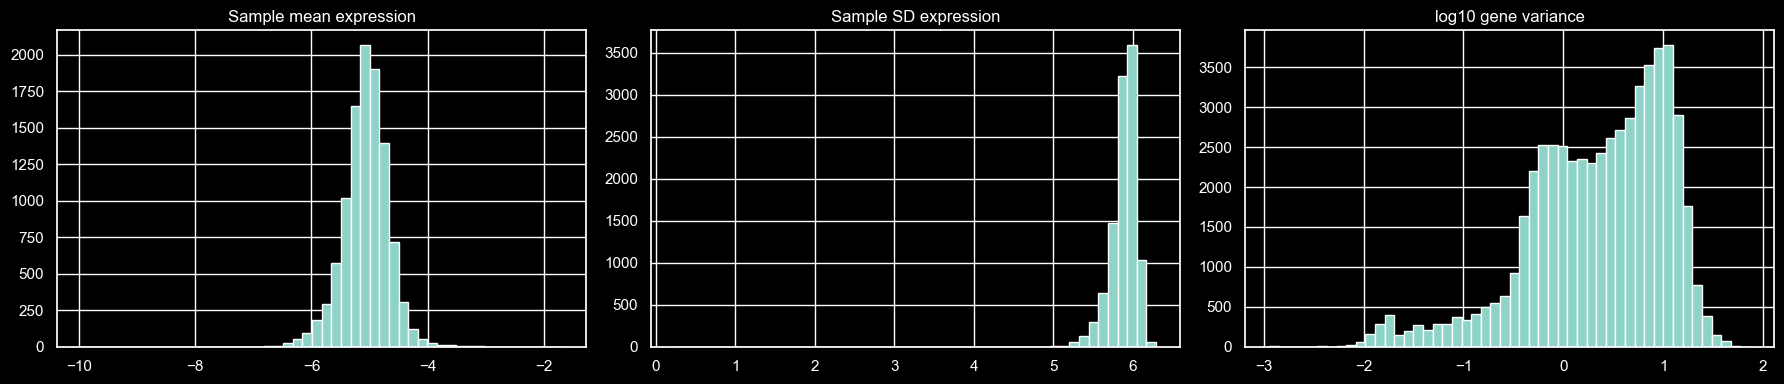

In [11]:
# Distribution checks
sample_means = rna_mat.mean(axis=1)
sample_stds = rna_mat.std(axis=1)
gene_vars = rna_mat.var(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(sample_means, bins=50)
axes[0].set_title("Sample mean expression")

axes[1].hist(sample_stds, bins=50)
axes[1].set_title("Sample SD expression")

axes[2].hist(np.log10(gene_vars.replace(0, np.nan).dropna()), bins=50)
axes[2].set_title("log10 gene variance")
plt.tight_layout()
plt.show()

## TP53 mutation label construction

This is the most important part of EDA.
We want a sample-level TP53 label built from all TP53 mutation rows, not just one selected row.

In [12]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()

tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

print("TP53 mutation rows:", tp53_rows.shape)
display(tp53_rows.head())
preview_cols = [c for c in [MUT_SAMPLE_COL, "sample_id", "patient_id", MUT_GENE_COL, "effect_text"] if c in tp53_rows.columns]
display(tp53_rows[preview_cols].head())

TP53 mutation rows: (3729, 15)


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen,patient_id,sample_id,effect_text
19,TCGA-02-0003-01,17,7577094,7577094,G,A,TP53,Missense_Mutation,p.R282W,0.43,deleterious(0),probably_damaging(0.997),TCGA-02-0003,TCGA-02-0003-01,Missense_Mutation | p.R282W
20,TCGA-02-0003-01,17,7578396,7578396,G,T,TP53,Missense_Mutation,p.H178Q,0.38,deleterious(0),probably_damaging(1),TCGA-02-0003,TCGA-02-0003-01,Missense_Mutation | p.H178Q
80,TCGA-02-0033-01,17,7577538,7577538,C,T,TP53,Missense_Mutation,p.R248Q,0.26,deleterious(0),probably_damaging(1),TCGA-02-0033,TCGA-02-0033-01,Missense_Mutation | p.R248Q
211,TCGA-02-0055-01,17,7578203,7578203,C,T,TP53,Missense_Mutation,p.V216M,0.61,deleterious(0),probably_damaging(1),TCGA-02-0055,TCGA-02-0055-01,Missense_Mutation | p.V216M
363,TCGA-02-2483-01,17,7577120,7577120,C,T,TP53,Missense_Mutation,p.R273H,0.90,tolerated(0.13),possibly_damaging(0.631),TCGA-02-2483,TCGA-02-2483-01,Missense_Mutation | p.R273H


,sample,sample_id,patient_id,gene,effect_text
19,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,TP53,Missense_Mutation | p.R282W
20,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,TP53,Missense_Mutation | p.H178Q
80,TCGA-02-0033-01,TCGA-02-0033-01,TCGA-02-0033,TP53,Missense_Mutation | p.R248Q
211,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,TP53,Missense_Mutation | p.V216M
363,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,TP53,Missense_Mutation | p.R273H


In [13]:
tp53_rows["effect_text"].value_counts(dropna=False).head(30)

effect_text
Missense_Mutation | p.R175H    124
Missense_Mutation | p.R248Q    110
Missense_Mutation | p.R273C    110
Missense_Mutation | p.R273H     90
Missense_Mutation | p.R282W     78
Missense_Mutation | p.R248W     68
Nonsense_Mutation | p.R213*     68
Missense_Mutation | p.Y220C     53
Nonsense_Mutation | p.R196*     45
Splice_Site | p.X187_splice     41
Missense_Mutation | p.G245S     39
Silent | p.T125T                38
Missense_Mutation | p.H179R     34
Splice_Site | p.X126_splice     32
Missense_Mutation | p.V157F     29
Nonsense_Mutation | p.R342*     28
Nonsense_Mutation | p.R306*     28
Splice_Site | p.X307_splice     25
Splice_Site | p.X225_splice     25
Missense_Mutation | p.R249S     25
Missense_Mutation | p.H193R     24
Missense_Mutation | p.R273L     24
Missense_Mutation | p.R158L     24
Missense_Mutation | p.E285K     24
Missense_Mutation | p.Y163C     21
Missense_Mutation | p.C176F     21
Splice_Site | p.X331_splice     21
Nonsense_Mutation | p.Q192*     20
Missense

In [14]:
PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frameshift", "frame_shift", "splice",
    "nonstop", "stop_gained", "stop_lost", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous",
}

SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frameshift", "frame_shift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["other_or_unknown", "unknown"])

display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))

,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


### Important
Later, the main label should usually be:

- `TP53_mut_nonsyn = 1` if a sample has any nonsynonymous / protein-altering TP53 event
- `0` otherwise

But for EDA we should also track ambiguity:
- does the sample have any ambiguous TP53 row?
- does it have multiple TP53 rows?
- does it have mixed TP53 annotations?

In [15]:
tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id_from_tp53=("patient_id", "first"),
        n_tp53_rows=(MUT_GENE_COL, "size"),
        has_any_tp53_row=(MUT_GENE_COL, lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

display(tp53_sample.head())
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("rate"))

,sample_id,patient_id_from_tp53,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,Missense_Mutation | p.R282W; Missense_Mutation...,1,0,0
1,TCGA-02-0033-01,TCGA-02-0033,1,True,True,False,1,Missense_Mutation | p.R248Q,1,0,0
2,TCGA-02-0055-01,TCGA-02-0055,1,True,True,False,1,Missense_Mutation | p.V216M,1,0,0
3,TCGA-02-2483-01,TCGA-02-2483,1,True,True,False,1,Missense_Mutation | p.R273H,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,Missense_Mutation | p.R248Q; Missense_Mutation...,1,0,0


,rate
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [16]:
# Samples with multiple TP53 rows or mixed annotation
display(
    tp53_sample.loc[
        (tp53_sample["n_tp53_rows"] > 1) | (tp53_sample["has_mixed_tp53_annotation"] == 1)
    ].head(20)
)

,sample_id,patient_id_from_tp53,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,Missense_Mutation | p.R282W; Missense_Mutation...,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,Missense_Mutation | p.R248Q; Missense_Mutation...,1,0,0
14,TCGA-05-4405-01,TCGA-05-4405,2,True,True,False,1,Missense_Mutation | p.C277F; Missense_Mutation...,1,0,0
22,TCGA-05-4432-01,TCGA-05-4432,2,True,True,False,2,Nonsense_Mutation | p.R342*; Missense_Mutation...,1,0,0
24,TCGA-05-5423-01,TCGA-05-5423,2,True,True,False,1,Missense_Mutation | p.R249M; Missense_Mutation...,1,0,0
31,TCGA-06-0188-01,TCGA-06-0188,2,True,True,False,2,Missense_Mutation | p.A307V; Splice_Site | p.X...,1,0,0
34,TCGA-06-0195-01,TCGA-06-0195,2,True,True,False,1,Missense_Mutation | p.D281A; Missense_Mutation...,1,0,0
46,TCGA-06-2559-01,TCGA-06-2559,2,True,True,False,1,Missense_Mutation | p.P190L; Missense_Mutation...,1,0,0
48,TCGA-06-2567-01,TCGA-06-2567,2,True,True,False,2,Missense_Mutation | p.E271K; Nonsense_Mutation...,1,0,0
53,TCGA-06-5417-01,TCGA-06-5417,2,True,True,False,2,Missense_Mutation | p.I255S; Nonsense_Mutation...,1,0,0


In [17]:
print("Phenotype sample column:", PHENO_SAMPLE_COL)
print("Phenotype patient column:", PHENO_PATIENT_COL)
print("Cancer-type column:", CANCER_TYPE_COL)
print("Cancer-type counts preview:")
display(pheno_raw[CANCER_TYPE_COL].value_counts(dropna=False).head(20).to_frame("n"))

Phenotype sample column: sample
Phenotype patient column: _PATIENT
Cancer-type column: cancer type abbreviation
Cancer-type counts preview:


,n
cancer type abbreviation,
BRCA,1236
KIRC,944
LUAD,641
LUSC,623
HNSC,604
OV,604
GBM,602
UCEC,583
THCA,580


In [18]:
pheno = pheno_raw.copy()
pheno["sample_id"] = pheno[PHENO_SAMPLE_COL].map(normalize_sample_id)

if PHENO_PATIENT_COL is not None:
    pheno["patient_id_from_pheno"] = pheno[PHENO_PATIENT_COL].map(normalize_patient_id)
else:
    pheno["patient_id_from_pheno"] = pheno["sample_id"].map(normalize_patient_id)

pheno["patient_id_from_pheno"] = pheno["patient_id_from_pheno"].fillna(pheno["sample_id"].map(normalize_patient_id))
pheno["sample_type_code"] = pheno["sample_id"].map(tcga_sample_type_code)
pheno["sample_type_label"] = pheno["sample_id"].map(tcga_sample_type_label)
pheno["is_tumor_sample"] = pheno["sample_id"].map(is_tcga_tumor_sample)

preview_cols = [PHENO_SAMPLE_COL, "sample_id", "patient_id_from_pheno", "sample_type_code", "sample_type_label", CANCER_TYPE_COL]
display(pheno[preview_cols].head())

,sample,sample_id,patient_id_from_pheno,sample_type_code,sample_type_label,cancer type abbreviation
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1-01,TCGA-OR-A5J1,01,Primary Solid Tumor,ACC
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2-01,TCGA-OR-A5J2,01,Primary Solid Tumor,ACC
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3-01,TCGA-OR-A5J3,01,Primary Solid Tumor,ACC
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4-01,TCGA-OR-A5J4,01,Primary Solid Tumor,ACC
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5-01,TCGA-OR-A5J5,01,Primary Solid Tumor,ACC


In [19]:
# Search for sample-type / tumour-normal / purity-like columns
candidate_sampletype_cols = [c for c in pheno.columns if "sample type" in c.lower() or "tumor" in c.lower() or "normal" in c.lower()]
candidate_purity_cols = [c for c in pheno.columns if "purity" in c.lower()]

print("Candidate sample-type columns:", candidate_sampletype_cols)
print("Candidate purity columns:", candidate_purity_cols)

Candidate sample-type columns: ['ajcc_pathologic_tumor_stage', 'tumor_status', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'residual_tumor', 'is_tumor_sample']
Candidate purity columns: []


In [20]:
rna_df = rna_mat.copy().reset_index()

merged = (
    rna_df
    .merge(tp53_sample, on="sample_id", how="left")
    .merge(pheno, on="sample_id", how="left")
)

# Critical fix: use phenotype/sample-derived patient IDs as the authoritative source for all samples.
# Mutation-derived patient IDs exist mainly for mutation-positive samples and would make many negatives look missing.
merged["patient_id"] = merged["patient_id_from_pheno"].combine_first(merged.get("patient_id_from_tp53"))
merged["patient_id"] = merged["patient_id"].fillna(merged["sample_id"].map(normalize_patient_id))

print("Merged shape:", merged.shape)
print("Missing patient_id after phenotype backfill:", int(merged["patient_id"].isna().sum()))
display(merged.head())

Merged shape: (10535, 60548)
Missing patient_id after phenotype backfill: 0


,sample_id,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1,ENSG00000078237.5,ENSG00000269416.5,ENSG00000263642.1,ENSG00000146083.11,ENSG00000158486.13,ENSG00000273639.4,ENSG00000198242.13,ENSG00000231981.3,ENSG00000269475.2,ENSG00000134108.12,ENSG00000261030.1,ENSG00000172137.18,ENSG00000276644.4,ENSG00000240423.1,ENSG00000271616.1,ENSG00000234881.1,ENSG00000236040.1,ENSG00000231105.1,ENSG00000094963.13,ENSG00000182141.9,ENSG00000280143.1,ENSG00000251334.2,ENSG00000231112.1,ENSG00000258610.1,ENSG00000264981.1,ENSG00000275265.1,ENSG00000185105.4,ENSG00000233540.1,ENSG00000102174.8,ENSG00000166391.14,ENSG00000232001.1,ENSG00000270469.1,ENSG00000225275.4,ENSG00000234253.1,ENSG00000070087.13,ENSG00000262950.1,ENSG00000255420.1,ENSG00000280038.1,ENSG00000153561.12,ENSG00000251538.5,ENSG00000269148.1,ENSG00000253438.2,ENSG00000235411.1,ENSG00000179262.9,ENSG00000278099.1,ENSG00000104833.10,ENSG00000166368.2,ENSG00000206072.12,ENSG00000006695.10,ENSG00000258630.1,ENSG00000187513.8,ENSG00000225269.2,ENSG00000214062.5,ENSG00000095587.8,ENSG00000167700.8,ENSG00000274219.1,ENSG00000254102.1,ENSG00000265096.1,ENSG00000064601.16,ENSG00000227766.1,ENSG00000008517.16,ENSG00000264085.1,ENSG00000261475.2,ENSG00000229637.3,ENSG00000266644.1,ENSG00000227896.2,ENSG00000214541.3,ENSG00000070081.15,ENSG00000166634.6,ENSG00000275479.1,ENSG00000112309.10,ENSG00000199812.1,ENSG00000261789.1,ENSG00000254092.1,ENSG00000158480.10,ENSG00000197421.9,ENSG00000280171.1,ENSG00000260900.1,ENSG00000266579.1,ENSG00000278732.1,ENSG00000196167.9,ENSG00000264438.2,ENSG00000200288.1,ENSG00000207000.1,ENSG00000254131.1,ENSG00000118972.1,ENSG00000264104.1,ENSG00000179833.4,ENSG00000165312.6,ENSG00000159618.15,ENSG00000064225.12,ENSG00000221372.1,ENSG00000250571.6,ENSG00000057294.13,...,ENSG00000241667.1,ENSG00000279507.1,ENSG00000162999.12,ENSG00000099991.16,ENSG00000212518.1,ENSG00000102265.11,ENSG00000133313.14,ENSG00000231700.3,ENSG00000214216.10,ENSG00000263414.1,ENSG00000265064.1,ENSG00000279778.1,ENSG00000223671.2,ENSG00000263573.1,ENSG00000222213.1,ENSG00000214124.3,ENSG00000206836.1,ENSG00000233845.1,ENSG00000066044.13,ENSG00000264491.1,ENSG00000146587.17,ENSG00000278151.1,ENSG00000228658.1,ENSG00000173930.8,ENSG00000274396.1,ENSG00000107863.16,ENSG00000199892.2,ENSG00000221760.1,ENSG00000253333.1,ENSG00000213782.7,ENSG00000146707.14,ENSG00000212084.2,ENSG00000248838.2,ENSG00000255083.1,ENSG00000158417.10,ENSG00000223665.1,ENSG00000203729.8,ENSG00000238300.1,ENSG00000221756.1,ENSG00000089177.17,ENSG00000186115.12,ENSG00000009694.13,ENSG00000238244.3,ENSG00000216352.1,ENSG00000123685.8,ENSG00000267117.1,ENSG00000273233.1,ENSG00000105063.18,ENSG00000231119.2,ENSG00000280861.1,ENSG00000181518.3,patient_id_from_tp53,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction,patient_id_from_pheno,sample_type_code,sample_type_label,is_tumor_sample,patient_id
0,TCGA-02-0047-01,0.0158,-9.9658,-0.8863,5.9750,-9.9658,3.7313,0.4865,-9.9658,4.5922,-9.9658,-9.9658,9.7099,-9.9658,-3.1714,6.2411,-9.9658,1.8996,-1.5951,-2.3884,-9.9658,-9.9658,-9.9658,-2.9324,-1.5105,2.6487,0.9038,-1.6850,-9.9658,3.1377,-9.9658,-9.9658,-1.0559,-2.4659,1.6558,-9.9658,-9.9658,-3.8160,-9.9658,-9.9658,9.0852,-9.9658,-9.9658,-3.4580,3.5174,-9.9658,-3.8160,-9.9658,-2.9324,6.3230,-9.9658,7.1125,-9.9658,-9.9658,2.6043,-9.9658,3.7072,-

In [21]:
# Mutation-negative samples should be explicit zeros
merged["TP53_mut_nonsyn"] = merged["TP53_mut_nonsyn"].fillna(0).astype(int)
merged["TP53_mut_ambiguous"] = merged["TP53_mut_ambiguous"].fillna(0).astype(int)
merged["has_any_tp53_row"] = merged["has_any_tp53_row"].fillna(False).astype(bool)
merged["has_mixed_tp53_annotation"] = merged["has_mixed_tp53_annotation"].fillna(0).astype(int)

display(
    merged[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_any_tp53_row", "has_mixed_tp53_annotation"]]
    .mean()
)

TP53_mut_nonsyn              0.287897
TP53_mut_ambiguous           0.001614
has_any_tp53_row             0.292359
has_mixed_tp53_annotation    0.000759
dtype: float64

## Cohort definition audit

Before finalizing the EDA cohort, check:
- duplicate sample IDs
- duplicate patient IDs
- missing cancer type
- possible normal samples
- multiple samples per patient

In [22]:
print("Pre-filter unique sample IDs:", merged["sample_id"].nunique())
print("Pre-filter rows:", len(merged))
print("Pre-filter unique patient IDs:", merged["patient_id"].nunique())
print("Pre-filter missing patient IDs:", int(merged["patient_id"].isna().sum()))
print("Pre-filter duplicated sample IDs:", int(merged["sample_id"].duplicated().sum()))
print("Pre-filter patients with >1 sample:", int((merged["patient_id"].value_counts() > 1).sum()))

display(merged[CANCER_TYPE_COL].value_counts(dropna=False).head(40).to_frame("n_samples_pre_filter"))

merged_unfiltered = merged.copy()

# Modeling cohort suggested by the EDA.  Later plots/tables use this clean cohort so that
# the EDA and modeling notebooks are aligned.
cohort = merged.copy()
cohort = cohort.loc[cohort["is_tumor_sample"].fillna(False)].copy()
cohort = cohort.loc[cohort[CANCER_TYPE_COL].notna()].copy()
cohort = cohort.loc[
    (cohort["TP53_mut_ambiguous"].fillna(0).astype(int) == 0) &
    (cohort["has_mixed_tp53_annotation"].fillna(0).astype(int) == 0)
].copy()

pre_dedup_n = len(cohort)
pre_dedup_multi_patient_counts = cohort["patient_id"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)

cohort["sample_priority"] = cohort["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
cohort = (
    cohort.sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cohort_summary = pd.Series({
    "n_rows_clean_cohort": len(cohort),
    "n_unique_samples_clean_cohort": cohort["sample_id"].nunique(),
    "n_unique_patients_clean_cohort": cohort["patient_id"].nunique(),
    "tp53_prevalence_clean_cohort": cohort["TP53_mut_nonsyn"].mean(),
    "n_cancer_types_clean_cohort": cohort[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(cohort_summary.to_frame("value"))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples_before_dedup"))

assert cohort["patient_id"].isna().sum() == 0, "Patient IDs should not be missing in the clean cohort."
assert cohort["patient_id"].nunique() == len(cohort), "Clean cohort should contain exactly one sample per patient."
assert cohort["sample_id"].nunique() == len(cohort), "Clean cohort should contain unique sample IDs."

# From this point onward, use the clean cohort for EDA summaries that guide modeling.
merged = cohort.copy()
print("Using clean tumour-only one-sample-per-patient cohort for downstream EDA tables and plots.")

Pre-filter unique sample IDs: 10535
Pre-filter rows: 10535
Pre-filter unique patient IDs: 9781
Pre-filter missing patient IDs: 0
Pre-filter duplicated sample IDs: 0
Pre-filter patients with >1 sample: 750


,n_samples_pre_filter
cancer type abbreviation,
BRCA,1211
KIRC,603
LUAD,574
THCA,571
HNSC,564
LUSC,548
PRAD,548
LGG,522
SKCM,470


,value
n_rows_clean_cohort,9695.000000
n_unique_samples_clean_cohort,9695.000000
n_unique_patients_clean_cohort,9695.000000
tp53_prevalence_clean_cohort,0.311604
n_cancer_types_clean_cohort,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


,n_samples_before_dedup
patient_id,
TCGA-SR-A6MX,3
TCGA-G4-6317,2
TCGA-J8-A4HW,2
TCGA-J8-A3YH,2
TCGA-J8-A3O2,2
TCGA-HZ-A9TJ,2
TCGA-HM-A6W2,2
TCGA-G5-6572,2
TCGA-FG-A4MT,2


Using clean tumour-only one-sample-per-patient cohort for downstream EDA tables and plots.


In [23]:
display(merged_unfiltered["sample_type_label"].value_counts(dropna=False).to_frame("n_pre_filter"))
display(merged["sample_type_label"].value_counts(dropna=False).to_frame("n_clean_cohort"))

,n_pre_filter
sample_type_label,
Primary Solid Tumor,9164
Solid Tissue Normal,712
Metastatic,392
Primary Blood Derived Cancer - Peripheral Blood,173
Recurrent Solid Tumor,44
NaN,39
Additional - New Primary,10
Additional Metastatic,1


,n_clean_cohort
sample_type_label,
Primary Solid Tumor,9149
Metastatic,362
Primary Blood Derived Cancer - Peripheral Blood,173
Recurrent Solid Tumor,11


### Cohort decision recorded

For modelling, use the same clean cohort summarized above:

- **Tumour-only:** Yes. Retain TCGA tumour sample type codes `01` through `09`; drop normal/control sample types.
- **One sample per patient:** Yes. Deduplicate by patient to avoid patient-level leakage between train/test folds.
- **Deduplication rule:** Prefer primary tumour (`01`) first, then blood-derived primary tumour (`03`), metastatic (`06`), recurrent (`02`), and other tumour codes in a fixed priority order.
- **Cancer type:** Keep a pan-cancer cohort, but require non-missing cancer type and treat cancer type as a key confounder in modelling.
- **Ambiguous TP53 labels:** Exclude ambiguous or mixed TP53 annotations from the modelling cohort.

In [24]:
label_summary = pd.Series({
    "n_samples": len(merged),
    "n_tp53_nonsyn": merged["TP53_mut_nonsyn"].sum(),
    "tp53_nonsyn_rate": merged["TP53_mut_nonsyn"].mean(),
    "n_tp53_ambiguous": merged["TP53_mut_ambiguous"].sum(),
    "ambiguous_rate": merged["TP53_mut_ambiguous"].mean(),
    "n_mixed_tp53_annotation": merged["has_mixed_tp53_annotation"].sum(),
})
display(label_summary.to_frame("value"))

,value
n_samples,9695.000000
n_tp53_nonsyn,3021.000000
tp53_nonsyn_rate,0.311604
n_tp53_ambiguous,0.000000
ambiguous_rate,0.000000
n_mixed_tp53_annotation,0.000000


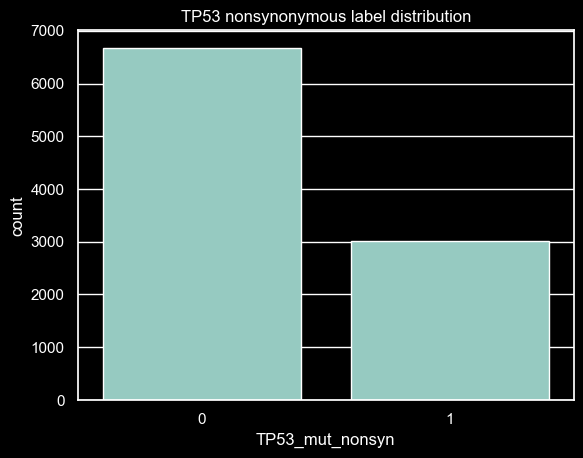

In [25]:
sns.countplot(data=merged, x="TP53_mut_nonsyn")
plt.title("TP53 nonsynonymous label distribution")
plt.show()

In [26]:
cancer_stats = (
    merged.groupby(CANCER_TYPE_COL)
    .agg(
        n_samples=("sample_id", "size"),
        tp53_rate=("TP53_mut_nonsyn", "mean"),
        n_tp53=("TP53_mut_nonsyn", "sum"),
    )
    .sort_values("n_samples", ascending=False)
)

display(cancer_stats.head(40))

,n_samples,tp53_rate,n_tp53
cancer type abbreviation,,,
BRCA,1090,0.239450,261
KIRC,530,0.020755,11
HNSC,518,0.677606,351
LUAD,513,0.500975,257
LGG,510,0.472549,241
THCA,504,0.005952,3
PRAD,495,0.117172,58
LUSC,495,0.795960,394
SKCM,464,0.146552,68


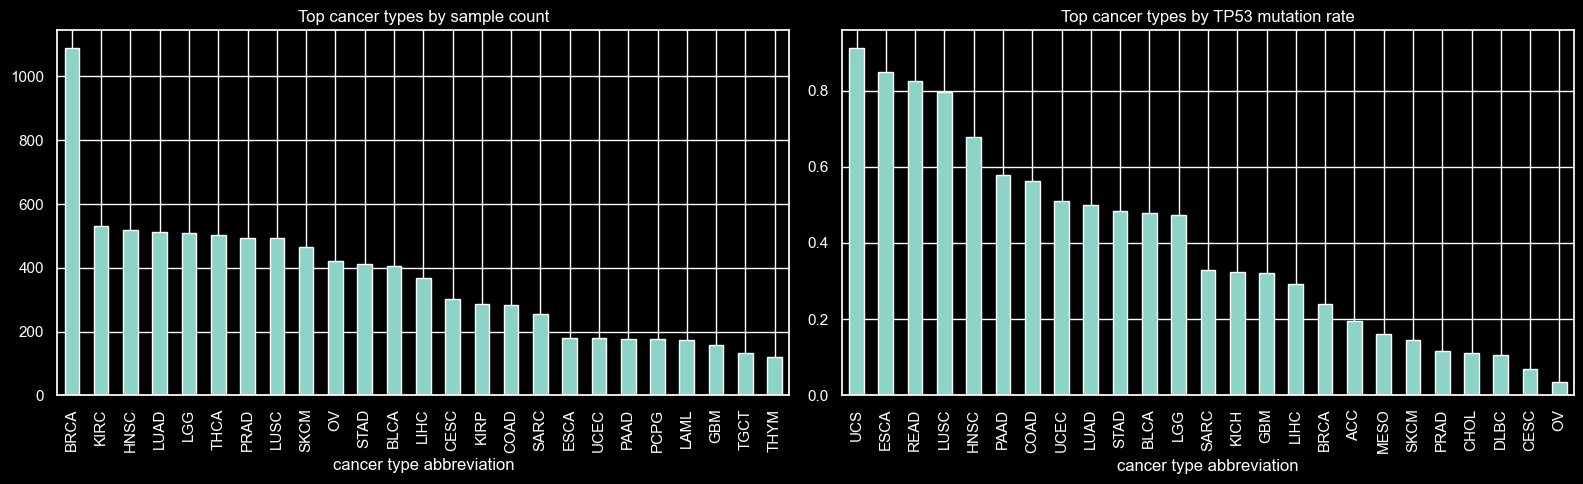

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cancer_stats["n_samples"].sort_values(ascending=False).head(25).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top cancer types by sample count")

cancer_stats["tp53_rate"].sort_values(ascending=False).head(25).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top cancer types by TP53 mutation rate")

plt.tight_layout()
plt.show()

### Interpretation guide

Use these outputs to decide how conservative the modelling evaluation must be:

- Strongly uneven TP53 prevalence across cancer types means a random pan-cancer split may partly reward learning tumour type.
- Small cancer-type groups should not drive cancer-specific conclusions.
- The modelling notebook should therefore report a cancer-type-only baseline, RNA-only model, RNA-plus-cancer-type model, and a cancer-type-grouped validation analysis.

In [28]:
metadata_cols_to_check = [CANCER_TYPE_COL, "patient_id", "sample_id"]
metadata_missing = merged[metadata_cols_to_check].isna().mean().sort_values(ascending=False)
display(metadata_missing.to_frame("missing_fraction"))

,missing_fraction
cancer type abbreviation,0.0
patient_id,0.0
sample_id,0.0


In [29]:
# If you identify purity / age / sex / stage columns
candidate_covariates = [c for c in merged.columns if any(k in c.lower() for k in ["purity", "age", "sex", "stage"])]
candidate_covariates[:30]

['age_at_initial_pathologic_diagnosis',
 'ajcc_pathologic_tumor_stage',
 'clinical_stage']

RNA feature count: 60498


count    60498.000000
mean         4.722314
std          5.744385
min          0.000000
25%          0.575435
50%          2.300550
75%          7.395138
max         74.718750
dtype: float64

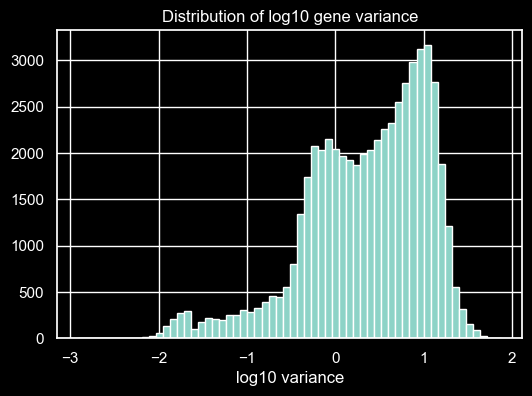

In [30]:
gene_cols = [c for c in merged.columns if c in rna_mat.columns]

expr = merged[gene_cols]

print("RNA feature count:", expr.shape[1])

gene_var = expr.var(axis=0)
display(gene_var.describe())

plt.figure(figsize=(6, 4))
plt.hist(np.log10(gene_var.replace(0, np.nan).dropna()), bins=60)
plt.title("Distribution of log10 gene variance")
plt.xlabel("log10 variance")
plt.show()

In [31]:
# Fraction of near-constant genes at a simple threshold
var_thresholds = [1e-6, 1e-4, 1e-3, 1e-2]
for t in var_thresholds:
    frac = (gene_var <= t).mean()
    print(f"Fraction genes with variance <= {t}: {frac:.3f}")

Fraction genes with variance <= 1e-06: 0.084
Fraction genes with variance <= 0.0001: 0.084
Fraction genes with variance <= 0.001: 0.084
Fraction genes with variance <= 0.01: 0.085


### RNA dimensionality conclusion

This EDA may motivate unsupervised, train-fold-only RNA filtering in the modelling notebook, such as removing genes with extreme floor-value frequency and retaining a fixed number of high-variance genes before supervised selection.

Do **not** use whole-dataset supervised RNA-label rankings from EDA as final feature selection; supervised selection must happen inside each modelling fold.

In [32]:
# Use top variable genes for stable PCA
top_var_genes = gene_var.sort_values(ascending=False).head(TOP_VAR_GENES_FOR_PCA).index.tolist()

X_pca_input = merged[top_var_genes].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.median())

X_scaled = StandardScaler().fit_transform(X_pca_input)
pca = PCA(n_components=10, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "TP53_mut_nonsyn": merged["TP53_mut_nonsyn"].values,
    CANCER_TYPE_COL: merged[CANCER_TYPE_COL].values,
})
display(pca_df.head())
print("Explained variance ratio:", pca.explained_variance_ratio_[:5])

,PC1,PC2,TP53_mut_nonsyn,cancer type abbreviation
0,-23.974586,-12.993590,0,GBM
1,-13.955592,-9.764033,1,GBM
2,-27.915874,-13.068973,1,GBM
3,-27.821421,-10.905892,1,GBM
4,-0.123689,-4.954304,0,OV


Explained variance ratio: [0.1145334  0.0562033  0.04338736 0.04042791 0.03392322]


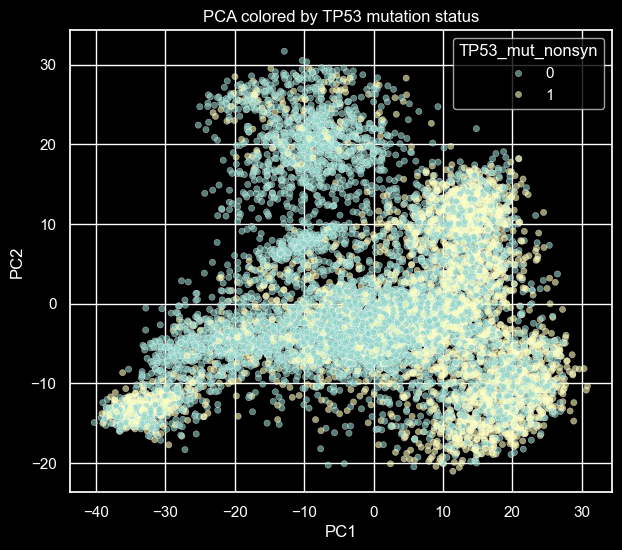

In [33]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="TP53_mut_nonsyn", alpha=0.6, s=20)
plt.title("PCA colored by TP53 mutation status")
plt.show()

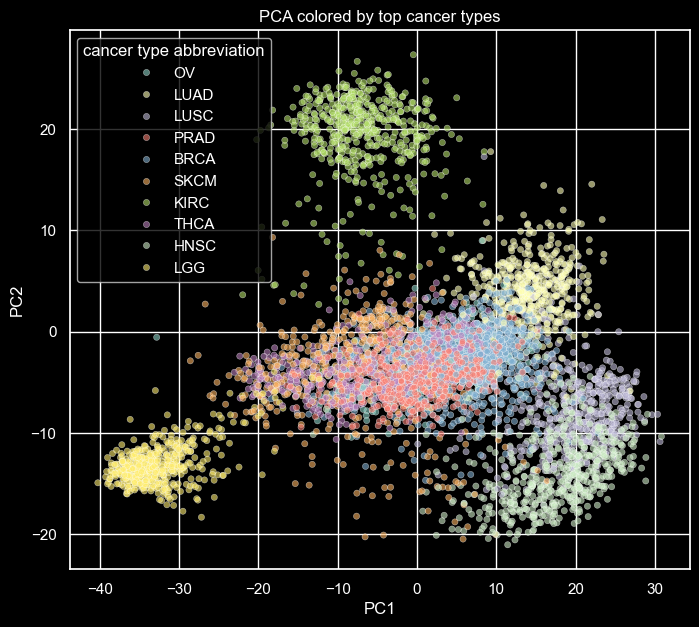

In [34]:
# Show only top cancer types to keep plot readable
top_types = cancer_stats.head(10).index
plot_df = pca_df[pca_df[CANCER_TYPE_COL].isin(top_types)].copy()

plt.figure(figsize=(8, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=CANCER_TYPE_COL, alpha=0.6, s=20)
plt.title("PCA colored by top cancer types")
plt.show()

### PCA interpretation rule

If PCA separates samples more strongly by cancer type than by TP53 status, the modelling notebook must treat cancer type as a confounder. The appropriate response is not to remove cancer type from consideration, but to compare RNA-only models against cancer-type-only baselines and grouped cancer-type validation.

In [35]:
# Optional if file is available
if TP53_TARGETS_PATH is not None and TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH)
    display(tp53_targets.head())
    print("Target list shape:", tp53_targets.shape)
else:
    print("No optional TP53 target list found.")

,gene_symbol
0,ABCA12
1,ABHD4
2,ABTB2
3,ACER2
4,ACTA2


Target list shape: (343, 1)


In [36]:
# Simple exploratory inspection of canonical TP53 pathway genes.
# RNA matrices sometimes use Ensembl IDs, so this cell attempts an optional gene-symbol mapping.
def strip_ensembl_version(x):
    return re.sub(r"\..*$", "", str(x))

def infer_ensembl_col(df):
    for col in ["ensembl_gene_id", "ensembl_gene_id_no_version", "Ensembl", "ENSEMBL", "gene_id", "id"]:
        if col in df.columns:
            return col
    return None

def infer_symbol_col(df):
    for col in ["gene_symbol", "symbol", "gene", "Gene", "HugoSymbol", "hgnc_symbol", "approved_symbol"]:
        if col in df.columns:
            return col
    return None

gene_cols = [c for c in merged.columns if c in rna_mat.columns]
gene_symbol_map = {}

# Direct symbol case.
for c in gene_cols:
    gene_symbol_map[str(c).upper()] = c

# Optional Ensembl annotation case.
if GENE_ANNOTATION_PATH is not None:
    annot = pd.read_csv(GENE_ANNOTATION_PATH, sep=None, engine="python", low_memory=False)
    ens_col = infer_ensembl_col(annot)
    sym_col = infer_symbol_col(annot)
    if ens_col is not None and sym_col is not None:
        annot_map = annot[[ens_col, sym_col]].dropna().copy()
        annot_map["ensembl_gene_id_no_version"] = annot_map[ens_col].map(strip_ensembl_version)
        annot_map = annot_map.drop_duplicates("ensembl_gene_id_no_version")
        col_by_ens = {strip_ensembl_version(c): c for c in gene_cols}
        for _, row in annot_map.iterrows():
            col = col_by_ens.get(row["ensembl_gene_id_no_version"])
            if col is not None:
                gene_symbol_map[str(row[sym_col]).upper()] = col

# Some Xena matrices encode feature IDs as SYMBOL|ENSG or ENSG|SYMBOL; catch simple pipe-delimited cases.
for c in gene_cols:
    parts = [p.strip() for p in str(c).split("|")]
    for p in parts:
        if p and not looks_like_ensembl(p):
            gene_symbol_map[p.upper()] = c

genes_of_interest = ["TP53", "MDM2", "CDKN1A", "BAX", "DDB2", "XPC", "FDXR", "RPS27L", "DRAM1", "EDA2R"]
matched = {g: gene_symbol_map[g] for g in genes_of_interest if g in gene_symbol_map}
print("Matched canonical genes:", matched)

if matched:
    mean_by_label = (
        merged.groupby("TP53_mut_nonsyn")[list(matched.values())]
        .mean()
        .T
        .rename(columns={0: "TP53_WT", 1: "TP53_MUT"})
    )
    mean_by_label.insert(0, "gene_symbol", [next(k for k, v in matched.items() if v == idx) for idx in mean_by_label.index])
    display(mean_by_label)
else:
    print("No canonical TP53 pathway symbols matched. Provide a gene annotation/probeMap file for biological interpretation.")

Matched canonical genes: {}
No canonical TP53 pathway symbols matched. Provide a gene annotation/probeMap file for biological interpretation.


In [37]:
# Quick effect-size style ranking, purely exploratory
group0 = merged.loc[merged["TP53_mut_nonsyn"] == 0, gene_cols]
group1 = merged.loc[merged["TP53_mut_nonsyn"] == 1, gene_cols]

effect_size = group1.mean(axis=0) - group0.mean(axis=0)
effect_df = effect_size.sort_values(ascending=False).rename("mean_diff").to_frame()

display(effect_df.head(20))
display(effect_df.tail(20))

,mean_diff
ENSG00000169469.8,4.562189
ENSG00000241794.1,4.439168
ENSG00000105388.14,4.316913
ENSG00000169474.4,4.215463
ENSG00000163216.6,4.207809
ENSG00000205420.10,4.201391
ENSG00000185479.5,4.079017
ENSG00000206075.13,3.850243
ENSG00000249395.2,3.803049
ENSG00000163209.14,3.793005


,mean_diff
ENSG00000234779.1,-1.781997
ENSG00000105707.13,-1.790545
ENSG00000227568.1,-1.791835
ENSG00000279208.1,-1.793080
ENSG00000196415.9,-1.811815
ENSG00000249494.5,-1.835939
ENSG00000238243.3,-1.844602
ENSG00000160678.11,-1.850451
ENSG00000151365.2,-1.892143
ENSG00000124564.17,-1.912419


### Warning
These exploratory RNA-label associations should not be used as final feature selection.
Any supervised selection must happen inside the modeling pipeline after splitting.

In [38]:
# Not full modeling yet — just descriptive prevalence by cancer type
display(
    merged.groupby(CANCER_TYPE_COL)["TP53_mut_nonsyn"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

cancer type abbreviation
UCS     0.912281
ESCA    0.850000
READ    0.824176
LUSC    0.795960
HNSC    0.677606
PAAD    0.578652
COAD    0.563380
UCEC    0.511111
LUAD    0.500975
STAD    0.484262
BLCA    0.477833
LGG     0.472549
SARC    0.328125
KICH    0.323077
GBM     0.320755
LIHC    0.291553
BRCA    0.239450
ACC     0.194805
MESO    0.160920
SKCM    0.146552
Name: TP53_mut_nonsyn, dtype: float64

If cancer type alone already strongly stratifies TP53 prevalence, the modeling notebook should include:
- a metadata-only baseline
- an RNA-only model
- a cancer-type-aware validation strategy

# EDA conclusions

## Proposed main label
- Primary target: `TP53_mut_nonsyn`, defined as at least one protein-altering / nonsynonymous TP53 event.
- Ambiguous or mixed TP53 annotations are tracked and excluded from the modelling cohort.

## Cohort definition for modelling
- Use tumour samples only.
- Require non-missing cancer type.
- Use phenotype/sample-derived patient IDs for all samples.
- Keep exactly one sample per patient to prevent patient-level leakage.
- Keep the analysis pan-cancer, but treat cancer type as a major confounder.

## Main findings to carry into modelling
- TP53 status is imbalanced, so AUPRC should be a primary metric.
- TP53 prevalence varies by cancer type, so cancer-type-only baselines and grouped cancer-type evaluation are required.
- RNA expression is high-dimensional, so filtering, scaling, and supervised selection must be fit inside each training fold.
- PCA should be interpreted mainly as a check for cancer-type structure rather than as evidence of TP53 separation.
- Biological interpretation requires gene-symbol mapping when RNA features are Ensembl IDs.

## Modelling notebook plan
- Dummy prevalence baseline.
- Cancer-type-only baseline.
- RNA-only regularized logistic regression as the main scientific model.
- RNA plus cancer type as a secondary combined model.
- Cancer-type-grouped evaluation and within-cancer checks to assess confounding.